# Exploratory Data Analysis (EDA) - Job Search and Application Optimizer based on AI

## Job Description Dataset

This notebook presents an exploratory data analysis of a job listings dataset. The goal is to understand the structure, identify data quality issues, and extract meaningful insights to support further modeling.

Class: TC5035.10
Team: 60

- Main proposal: https://docs.google.com/document/d/1Mz4UCXaHjD5owqZ2oFoiThBTcC2Dnv-DvTM3Rf65L58/edit?tab=t.0
- Dataset: https://www.kaggle.com/datasets/ravindrasinghrana/job-description-dataset

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

sns.set(style="whitegrid")

In [36]:
df = pd.read_csv("../data/job_descriptions.csv")
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


## Data Structure Overview

We analyze the shape, data types, and general structure of the dataset.

In [37]:
df.shape

(1615940, 23)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  str    
 2   Qualifications    1615940 non-null  str    
 3   Salary Range      1615940 non-null  str    
 4   location          1615940 non-null  str    
 5   Country           1615940 non-null  str    
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  str    
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  str    
 11  Preference        1615940 non-null  str    
 12  Contact Person    1615940 non-null  str    
 13  Contact           1615940 non-null  str    
 14  Job Title         1615940 non-null  str    
 15  Role              1615940 non-null  str    
 16  Job Portal 

In [39]:
df.describe(include="all")

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
count,1.615940e+06,1615940,1615940,1615940,1615940,1615940,1.615940e+06,1.615940e+06,1615940,1.615940e+06,...,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1615940,1610462
unique,NaN,48,10,561,214,216,NaN,NaN,5,NaN,...,1615933,147,376,16,376,11,376,375,888,884
top,NaN,5 to 8 Years,BBA,$59K-$88K,Seoul,Malta,NaN,NaN,Part-Time,NaN,...,+1-507-963-5920,UX/UI Designer,Interaction Designer,FlexJobs,Interaction Designers specialize in designing ...,"{'Childcare Assistance, Paid Time Off (PTO), R...",Interaction design principles User behavior an...,"Work on interaction design, defining how users...",DTE Energy,"{""Sector"":""Automotive"",""Industry"":""Automotive""..."
freq,NaN,34120,162148,3043,15104,7723,NaN,NaN,324044,NaN,...,2,48551,20580,129879,20580,161924,20580,20580,1957,3572
mean,1.548935e+15,NaN,NaN,NaN,NaN,NaN,1.937743e+01,1.639926e+01,NaN,7.370467e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,8.946722e+14,NaN,NaN,NaN,NaN,NaN,2.355690e+01,7.066762e+01,NaN,3.529886e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.817948e+11,NaN,NaN,NaN,NaN,NaN,-4.090060e+01,-1.751982e+02,NaN,1.264600e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.740508e+14,NaN,NaN,NaN,NaN,NaN,5.152100e+00,-1.531010e+01,NaN,4.311400e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.547858e+15,NaN,NaN,NaN,NaN,NaN,1.807080e+01,1.914510e+01,NaN,7.363300e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.323729e+15,NaN,NaN,NaN,NaN,NaN,3.907420e+01,4.757690e+01,NaN,1.043000e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
df["desc_length"] = df["Job Description"].str.len()
df["skills_length"] = df["skills"].str.len()
df["resp_length"] = df["Responsibilities"].str.len()
df["skills_count"] = df["skills"].apply(lambda x: len(x.split(",")))

## Missing Values Analysis

We identify missing values and analyze their distribution.

In [41]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Company Profile     5478
Job Id                 0
Job Title              0
resp_length            0
skills_length          0
desc_length            0
Company                0
Responsibilities       0
skills                 0
Benefits               0
Job Description        0
Job Portal             0
Role                   0
Contact                0
Experience             0
Contact Person         0
Preference             0
Job Posting Date       0
Company Size           0
Work Type              0
longitude              0
latitude               0
Country                0
location               0
Salary Range           0
Qualifications         0
skills_count           0
dtype: int64

In [42]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Company Profile     0.338998
Job Id              0.000000
Job Title           0.000000
resp_length         0.000000
skills_length       0.000000
desc_length         0.000000
Company             0.000000
Responsibilities    0.000000
skills              0.000000
Benefits            0.000000
Job Description     0.000000
Job Portal          0.000000
Role                0.000000
Contact             0.000000
Experience          0.000000
Contact Person      0.000000
Preference          0.000000
Job Posting Date    0.000000
Company Size        0.000000
Work Type           0.000000
longitude           0.000000
latitude            0.000000
Country             0.000000
location            0.000000
Salary Range        0.000000
Qualifications      0.000000
skills_count        0.000000
dtype: float64

## Categorical Variables Cardinality

We evaluate the number of unique values for categorical variables.

In [43]:
categorical_cols = df.select_dtypes(include=["object"]).columns

cardinality = {col: df[col].nunique() for col in categorical_cols}
cardinality

/var/folders/3m/mq9yd779097d0kvtn4rhg2480000gq/T/ipykernel_16873/4062489727.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


{'Experience': 48,
 'Qualifications': 10,
 'Salary Range': 561,
 'location': 214,
 'Country': 216,
 'Work Type': 5,
 'Job Posting Date': 731,
 'Preference': 3,
 'Contact Person': 367128,
 'Contact': 1615933,
 'Job Title': 147,
 'Role': 376,
 'Job Portal': 16,
 'Job Description': 376,
 'Benefits': 11,
 'skills': 376,
 'Responsibilities': 375,
 'Company': 888,
 'Company Profile': 884}

## Univariate Analysis - Numerical Variables

In [44]:
numerical_cols = df.select_dtypes(include=np.number).columns.drop("Job Id")
numerical_cols

Index(['latitude', 'longitude', 'Company Size', 'desc_length', 'skills_length',
       'resp_length', 'skills_count'],
      dtype='str')

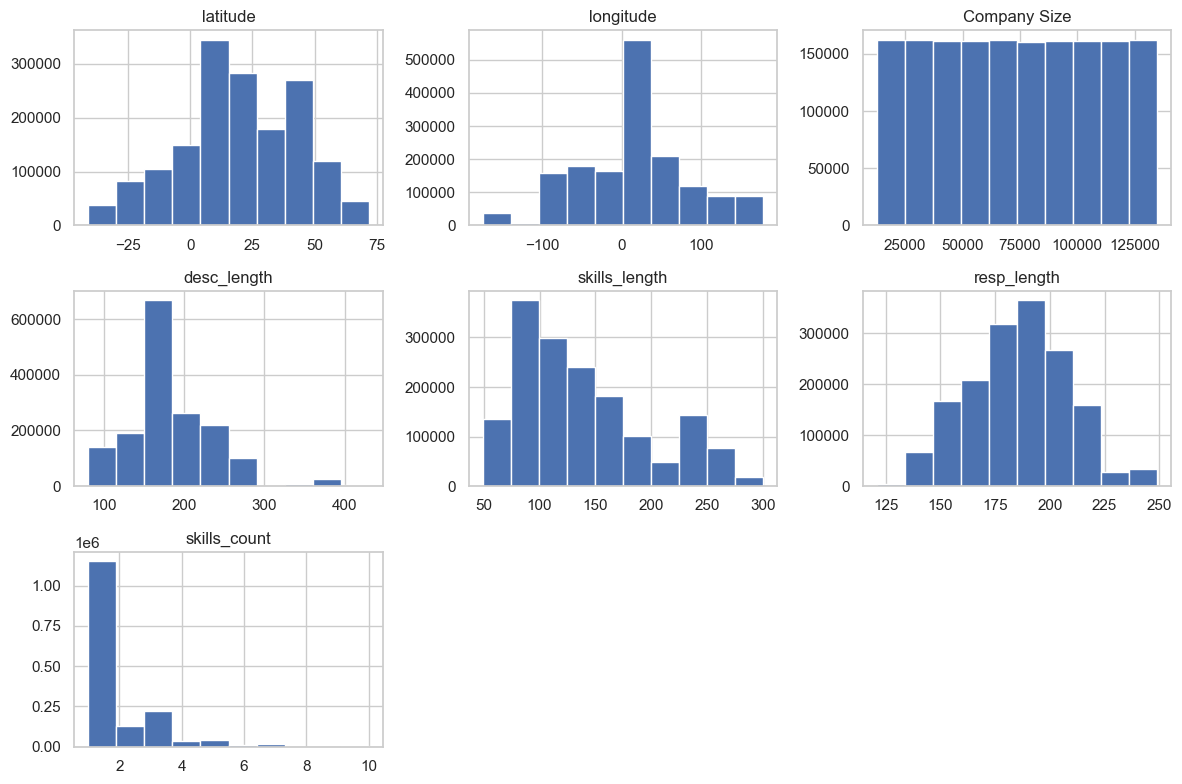

In [45]:
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

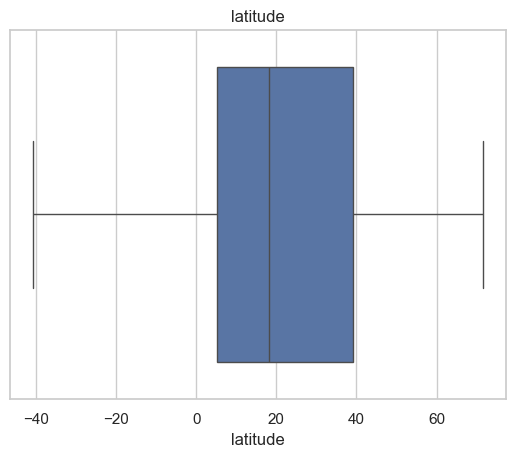

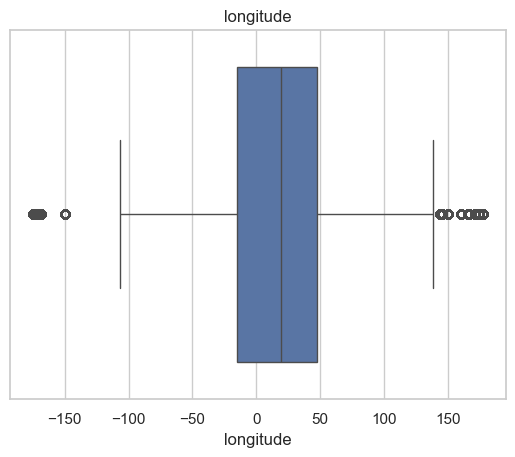

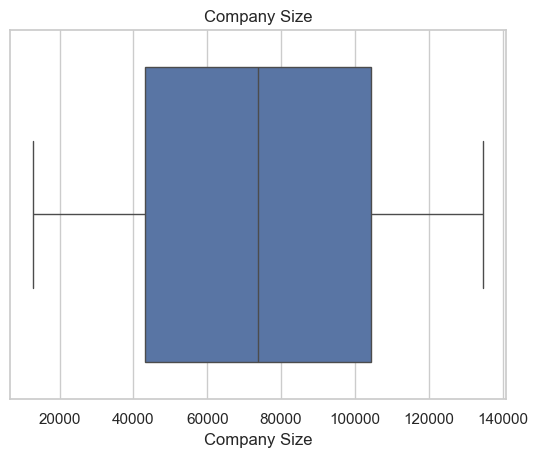

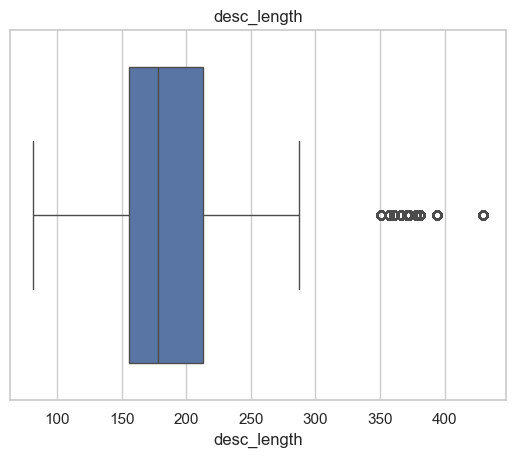

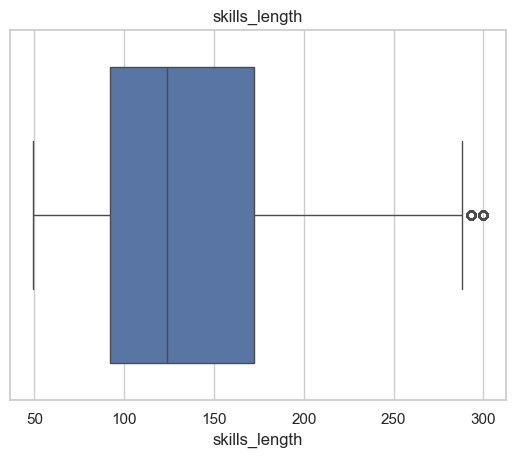

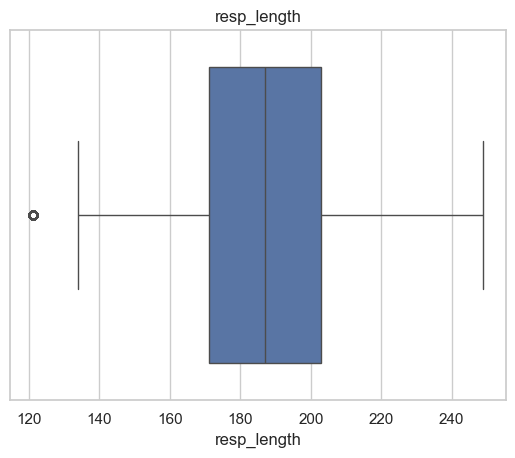

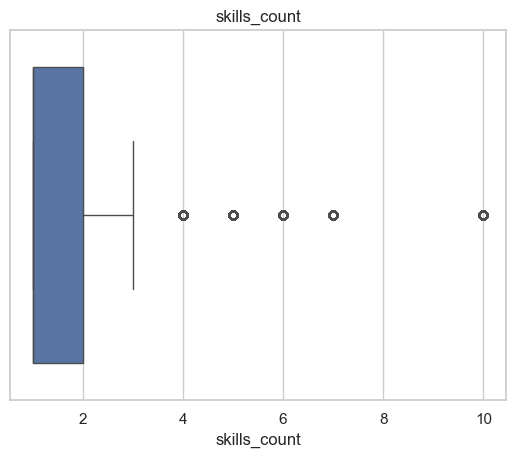

In [46]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Univariate Analysis - Categorical Variables

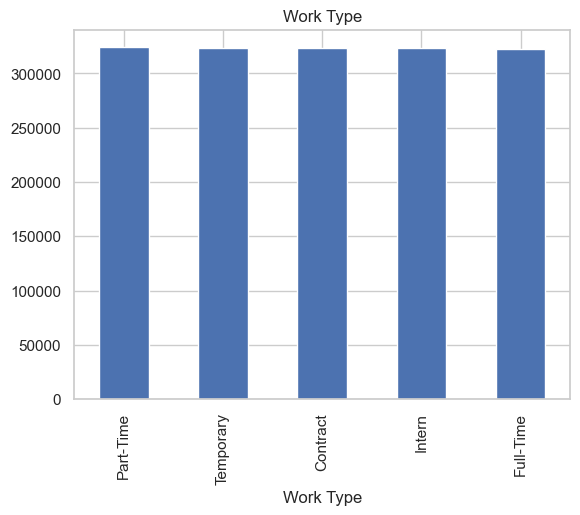

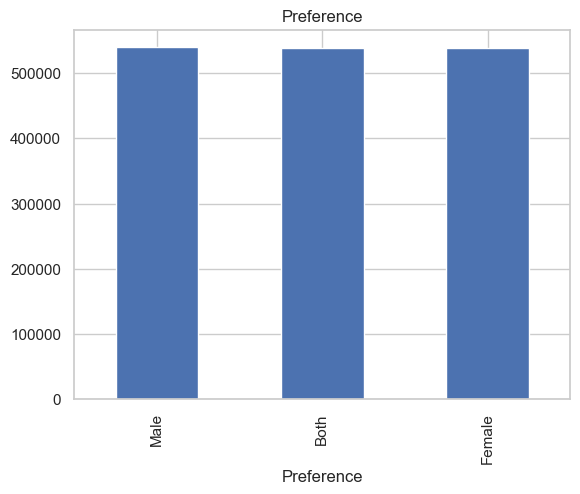

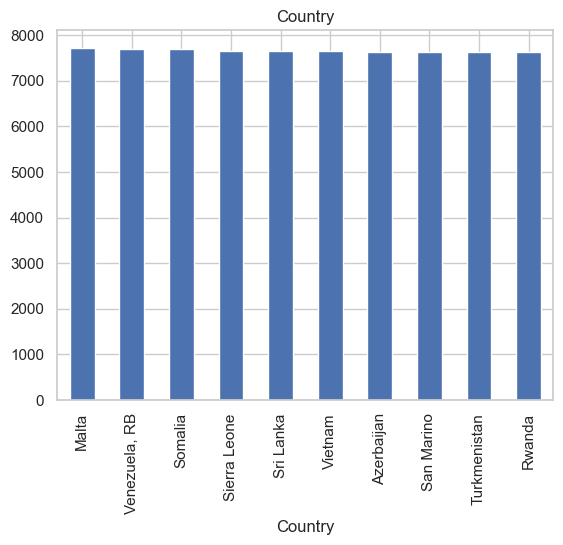

In [47]:
for col in ["Work Type", "Preference", "Country"]:
    plt.figure()
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(col)
    plt.show()

## Salary Cleaning

Salary ranges are transformed into numerical values for analysis.

In [48]:
def clean_salary(s):
    if pd.isna(s):
        return np.nan
    s = s.replace("$", "").replace("K", "000").replace("−", "-")
    parts = s.split("-")
    return (int(parts[0]) + int(parts[1])) / 2

df["Salary"] = df["Salary Range"].apply(clean_salary)

In [49]:
df["Salary"].head()

0    79000.0
1    86000.0
2    82500.0
3    78000.0
4    75500.0
Name: Salary, dtype: float64

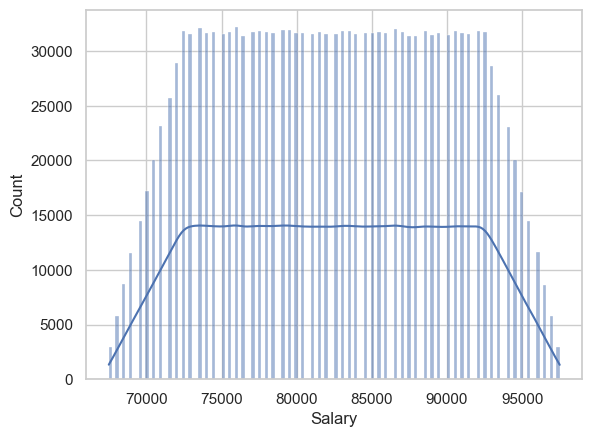

In [50]:
plt.figure()
sns.histplot(df["Salary"], kde=True)
plt.show()

In [51]:
def extract_experience(exp):
    exp = exp.replace("Years", "").strip()
    parts = exp.split("to")
    return (int(parts[0]) + int(parts[1])) / 2

df["Experience_num"] = df["Experience"].apply(extract_experience)

## Correlation Analysis

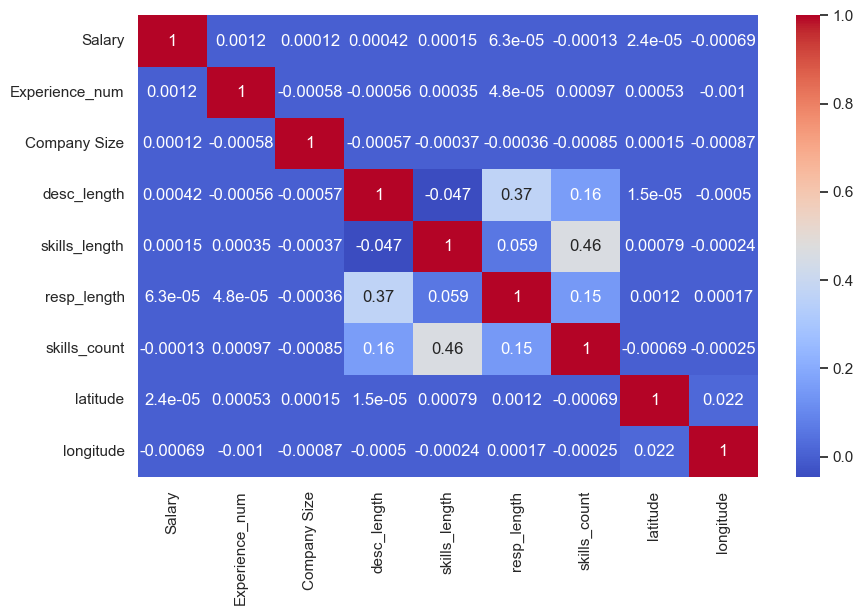

In [52]:
corr_cols = ["Salary", "Experience_num", "Company Size", "desc_length", "skills_length", "resp_length", "skills_count", "latitude", "longitude"]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Geographic Distribution

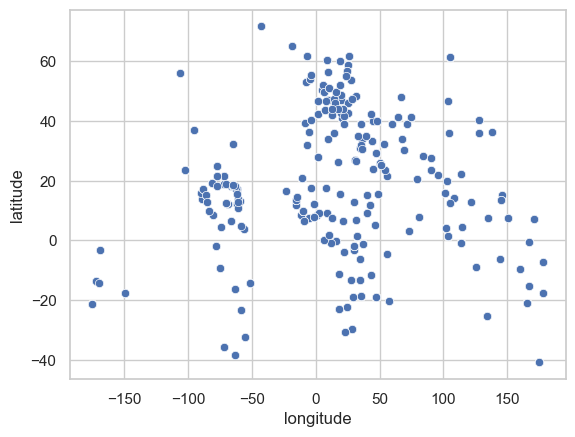

In [53]:
plt.figure()
sns.scatterplot(x=df["longitude"], y=df["latitude"])
plt.show()

In [54]:
# Add correlation against salary.
df[corr_cols].corr()["Salary"].sort_values(ascending=False)

Salary            1.000000
Experience_num    0.001214
desc_length       0.000420
skills_length     0.000148
Company Size      0.000124
resp_length       0.000063
latitude          0.000024
skills_count     -0.000127
longitude        -0.000691
Name: Salary, dtype: float64

In [55]:
# Compute high cardinality.
high_cardinality = {col: df[col].nunique() for col in categorical_cols if df[col].nunique() > 100}
high_cardinality

{'Salary Range': 561,
 'location': 214,
 'Country': 216,
 'Job Posting Date': 731,
 'Contact Person': 367128,
 'Contact': 1615933,
 'Job Title': 147,
 'Role': 376,
 'Job Description': 376,
 'skills': 376,
 'Responsibilities': 375,
 'Company': 888,
 'Company Profile': 884}

In [56]:
# Let's also add some encoding as well.
company_freq = df["Company"].value_counts().to_dict()
df["Company_freq"] = df["Company"].map(company_freq)

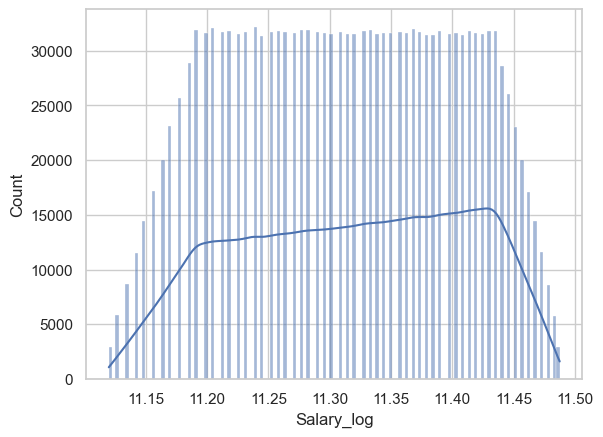

In [57]:
df["Salary_log"] = np.log1p(df["Salary"])

plt.figure()
sns.histplot(df["Salary_log"], kde=True)
plt.show()

## Temporal Trends

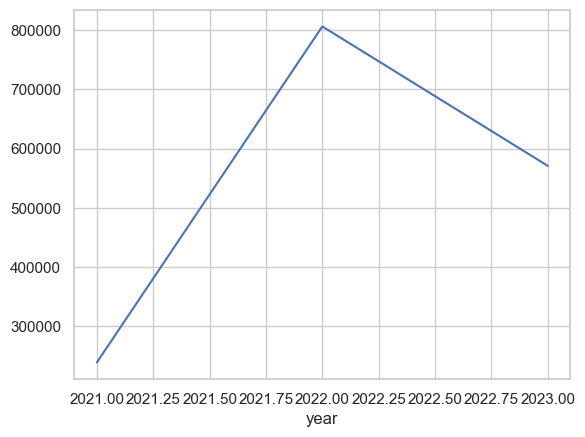

In [58]:
df["Job Posting Date"] = pd.to_datetime(df["Job Posting Date"])

df["year"] = df["Job Posting Date"].dt.year

df["year"].value_counts().sort_index().plot()
plt.show()

## Bivariate Analysis

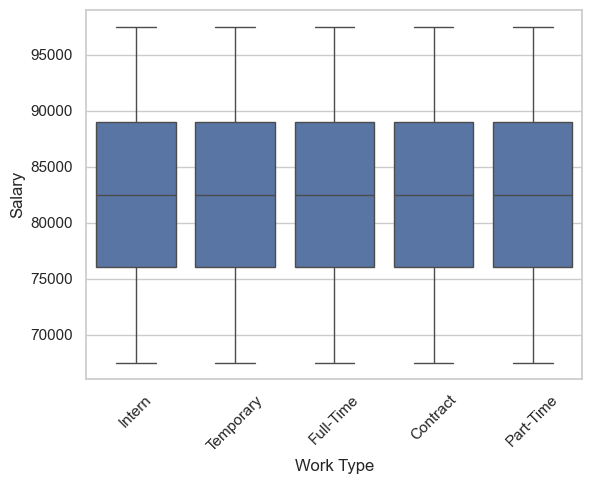

In [59]:
plt.figure()
sns.boxplot(x="Work Type", y="Salary", data=df)
plt.xticks(rotation=45)
plt.show()

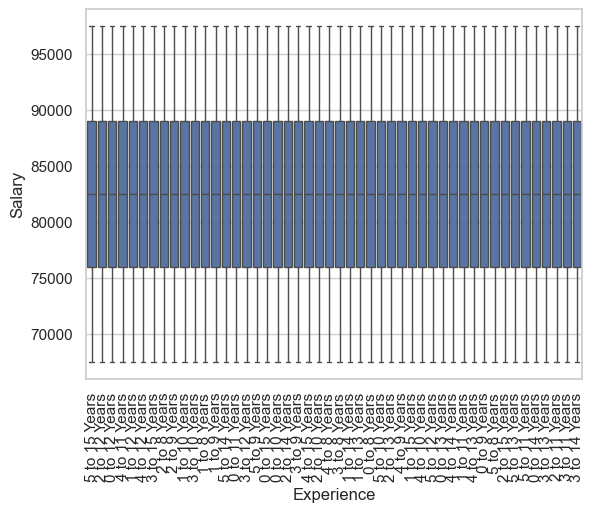

In [60]:
plt.figure()
sns.boxplot(x="Experience", y="Salary", data=df)
plt.xticks(rotation=90)
plt.show()

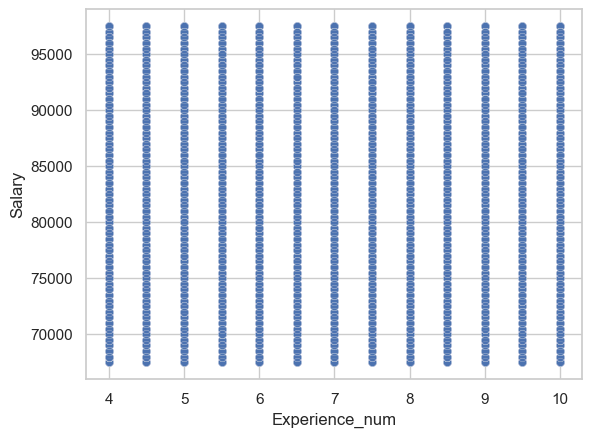

In [61]:
plt.figure()
sns.scatterplot(x="Experience_num", y="Salary", data=df, alpha=0.1)
plt.show()

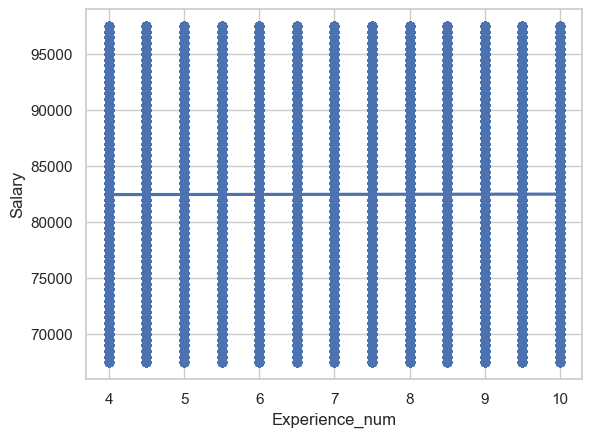

In [62]:
plt.figure()
sns.regplot(x="Experience_num", y="Salary", data=df, scatter_kws={"alpha":0.1})
plt.show()

## Outlier Detection

In [63]:
q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)
iqr = q3 - q1

outliers = df[(df["Salary"] < q1 - 1.5 * iqr) | (df["Salary"] > q3 + 1.5 * iqr)]
len(outliers)

0

In [64]:
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr

df["Salary_capped"] = df["Salary"].clip(lower_limit, upper_limit)

## Data Preprocessing

In [65]:
df = df.drop(columns=["Contact", "Contact Person", "Job Id"])

In [66]:
df["Company Size"] = pd.to_numeric(df["Company Size"], errors="coerce")

In [67]:
df = df.dropna(subset=["Salary"])

In [68]:
import re
from collections import Counter

sample_text = " ".join(df["Job Description"].sample(10000))
words = re.findall(r'\w+', sample_text.lower())

Counter(words).most_common(20)

[('and', 21992),
 ('to', 7845),
 ('they', 5920),
 ('a', 3598),
 ('the', 3292),
 ('in', 2930),
 ('with', 2697),
 ('data', 2453),
 ('user', 2011),
 ('ensure', 2001),
 ('for', 1926),
 ('of', 1872),
 ('on', 1745),
 ('or', 1561),
 ('provide', 1446),
 ('design', 1401),
 ('create', 1396),
 ('support', 1379),
 ('manage', 1244),
 ('an', 1231)]

## Feature Relevance Analysis

We evaluate feature importance using correlation and a tree-based model to identify the most relevant predictors of salary

In [69]:
model_df = df[[
    "Salary",
    "Experience_num",
    "Company Size",
    "desc_length",
    "skills_length",
    "resp_length",
    "skills_count",
    "Company_freq"
]].dropna()

In [70]:
X = model_df.drop(columns=["Salary"])
y = model_df["Salary"]

In [71]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [72]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

Company Size      0.379854
Company_freq      0.212565
desc_length       0.100299
skills_length     0.098226
Experience_num    0.094282
resp_length       0.092865
skills_count      0.021908
dtype: float64

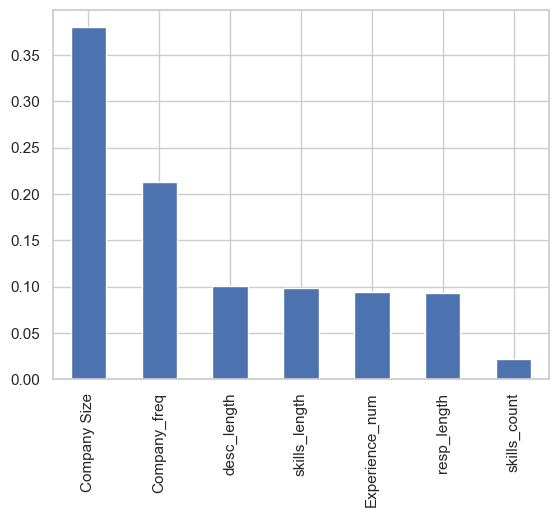

In [73]:
plt.figure()
importances.plot(kind="bar")
plt.show()

In [74]:
selected_features = importances[importances > 0.05].index.tolist()
selected_features

['Company Size',
 'Company_freq',
 'desc_length',
 'skills_length',
 'Experience_num',
 'resp_length']

In [75]:
df_model = model_df[selected_features + ["Salary"]]
df_model.head()

,Company Size,Company_freq,desc_length,skills_length,Experience_num,resp_length,Salary
0,26801,1911,200,172,10.0,210,79000.0
1,100340,1812,231,85,7.0,220,86000.0
2,84525,1820,222,199,6.0,191,82500.0
3,129896,1801,200,185,7.5,186,78000.0
4,53944,1828,235,114,6.5,158,75500.0


# EDA Findings and Conclusions

## Missing Values

The dataset contains very few missing values. Only the `Company Profile` column presents missing entries, with 5,478 null values, representing approximately 0.34% of the dataset. All other variables are complete.

No strong missing-value patterns were identified, suggesting that the dataset is generally well-structured and suitable for analysis without aggressive imputation strategies.

---

## Summary Statistics

The dataset contains 1,615,940 job postings and 23 variables.

Key numerical observations:

- `Company Size` has a mean of approximately 73,704 employees.
- Latitude values range from -40.90 to 71.70.
- Longitude values range from -175.20 to 178.06.
- Salary ranges were transformed into numerical salary estimates for analysis.

Key categorical observations:

- `Qualifications` contains 10 categories.
- `Work Type` contains 5 categories.
- `Country` contains 216 unique values.
- `Company` contains 888 unique values.

The dataset combines structured numerical data with high-dimensional textual information.

---

## Outlier Analysis

Outlier detection was performed using the IQR method on the salary variable.

No significant salary outliers were identified under the standard 1.5 × IQR rule. However, salary distributions still exhibit moderate variability, suggesting that capped or transformed versions may still improve modeling stability.

---

## Cardinality of Categorical Variables

Several categorical variables exhibit high cardinality:

- `Contact`: 1,615,933 unique values
- `Contact Person`: 367,128 unique values
- `Company`: 888 unique values
- `Role`: 376 unique values
- `Job Description`: 376 unique values

These variables may negatively affect machine learning models if encoded directly. Frequency encoding or feature extraction techniques are more appropriate for these cases.

---

## Skewed Distributions and Transformations

The salary distribution showed moderate skewness. To reduce skewness and stabilize variance, a logarithmic transformation (`log1p`) was applied to the salary variable.

Text-based features such as job description length and skills length also exhibited non-normal distributions.

---

## Temporal Trends

The dataset includes a temporal variable: `Job Posting Date`.

After converting the column to datetime format, yearly posting trends were analyzed. The dataset mainly contains job postings from 2022 and 2023, with relatively stable posting activity over time.

No major seasonal fluctuations were observed at the yearly aggregation level.

---

## Correlation Analysis

Correlation analysis revealed generally weak to moderate relationships between numerical features and salary.

The most relevant engineered features included:

- `Experience_num`
- `Company Size`
- `skills_count`
- `desc_length`

Feature relevance analysis using a Random Forest model confirmed that experience-related and text-derived variables contributed more strongly to salary prediction than geographic variables.

---

## Bivariate Analysis

Several bivariate analyses were performed:

- Salary distribution by `Work Type`
- Salary distribution by `Experience`
- Relationship between experience and salary using scatterplots and regression plots

Results suggest that higher experience levels tend to correspond to higher salary ranges, although variability remains high across categories.

Different work types also show distinct salary distributions.

---

## Image Normalization

This dataset does not contain image data; therefore, image normalization was not required.

---

## Class Imbalance

The `Work Type` variable shows moderate class imbalance.

Some categories, such as `Part-Time`, appear significantly more frequently than others. This imbalance should be considered during future modeling stages, especially for classification tasks.

## General Conclusions

- The dataset is large, diverse, and mostly clean.
- Textual variables represent an important source of information.
- High-cardinality categorical variables require preprocessing strategies.
- Salary and experience exhibit meaningful relationships.
- Feature engineering significantly improves feature relevance analysis.
- The dataset is suitable for predictive modeling and NLP applications.
- The exploratory analysis suggests that the dataset can be extended with synthetic ranking labels associated with specific professional roles, such as Software Engineer, Data Scientist, or Product Manager.
- By incorporating ranking scores for each job posting, the dataset can be transformed into a supervised learning problem where the model learns to predict the relevance or quality ranking of a job opportunity given its role, skills, experience requirements, and description.
- This preprocessing and feature engineering pipeline provides a strong foundation for building a job recommendation or ranking system.